In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import h5py
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

seed = 123

## Read the pre-processed dataset (see Task 1)

In [ ]:
data_dir = '../../data/frangieh'
adata = sc.read_h5ad(f"{data_dir}/dataset_pp_tim.h5ad")

## Define functions for clustering (including visualizatino with UMAP) and the required dimensionality reduction

In [3]:
from sklearn.cluster import KMeans
#from sklearn.metrics import adjusted_rand_score

def leiden(adata, resolution=1, title=None):
    sc.tl.leiden(adata, resolution=resolution, flavor='igraph', n_iterations=2, directed=False)
    sc.pl.umap(adata, color='leiden', title=title)

def kmeans(adata, k=8, title=None):
    sc.pp.pca(adata, n_comps=50)
    X_pca = adata.obsm['X_pca']
    kmeans = KMeans(n_clusters=k, random_state=seed).fit(X_pca)
    adata.obs['kmeans'] = kmeans.labels_.astype(str)
    sc.pl.umap(adata, color='kmeans', title=title)

def louvain(adata, resolution=1, title=None):
    sc.tl.louvain(adata, resolution=resolution)
    sc.pl.umap(adata, color='louvain', title=title)

In [4]:
adata_ctl = adata[adata.obs.perturbation_2.eq('Control')]
adata_IFN = adata[adata.obs.perturbation_2.eq('Co-culture')]
adata_co = adata[adata.obs.perturbation_2.eq('IFNγ')]

In [5]:
def dim_reduction(adata):
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

In [6]:
dim_reduction(adata_ctl)
dim_reduction(adata_IFN)
dim_reduction(adata_co)

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


## Perform clustering (leiden and kmeans) on each condition separately as the cells would cluster strongly by condition otherwise

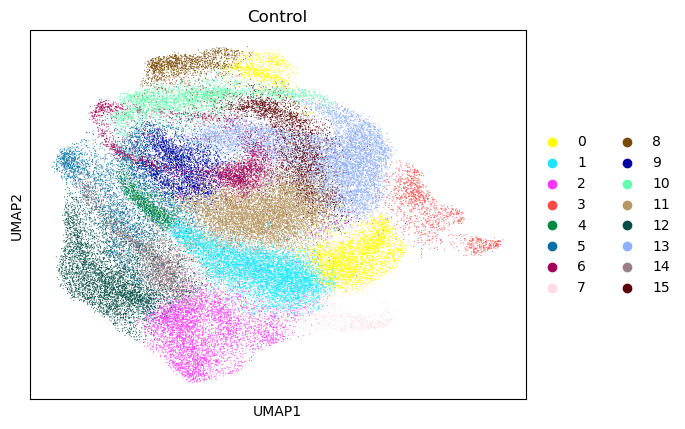

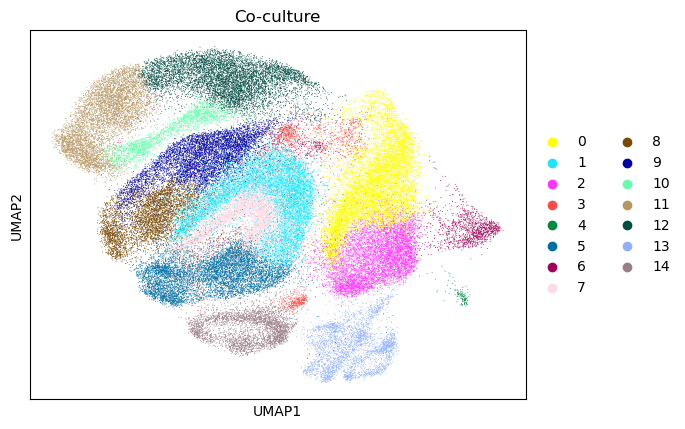

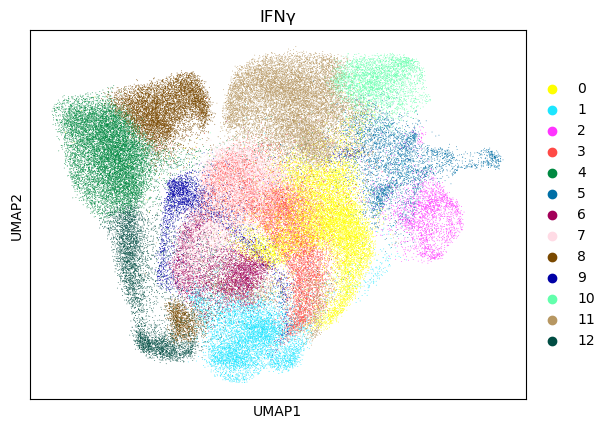

In [86]:
for condition_data in [adata_ctl, adata_IFN, adata_co]:
    leiden(condition_data, 0.7, condition_data.obs.perturbation_2.values[0])

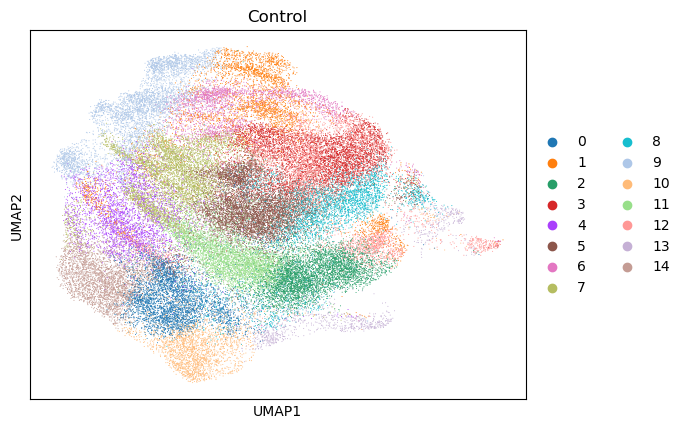

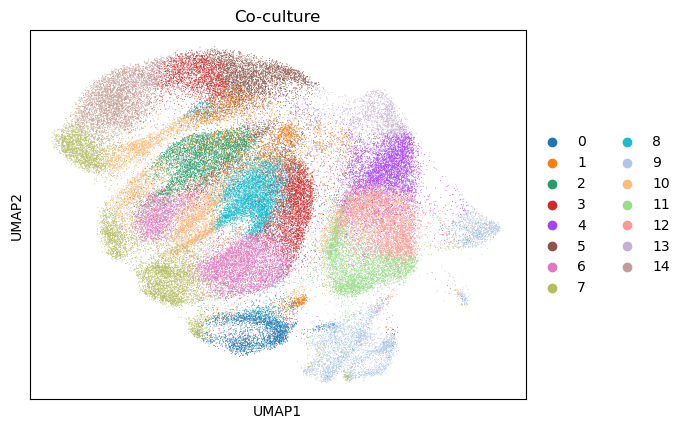

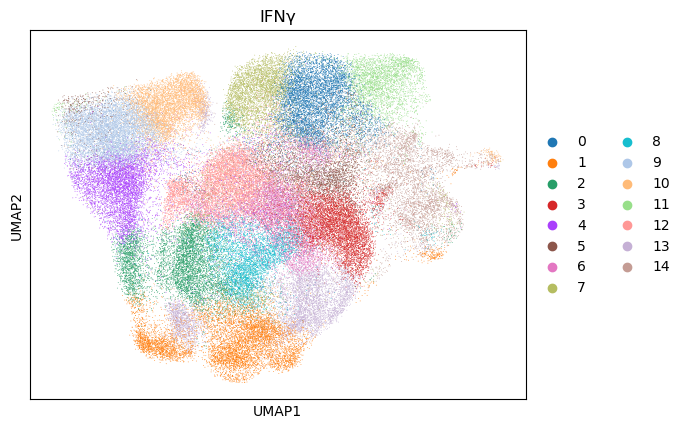

In [87]:
for condition_data in [adata_ctl, adata_IFN, adata_co]:
    kmeans(condition_data, 15, condition_data.obs.perturbation_2.values[0])

In [ ]:
for condition_data in [adata_ctl, adata_IFN, adata_co]:
    louvain(condition_data, 1, condition_data.obs.perturbation_2.values[0])

## Assign perturbations to clusters and plot the top perturbation per cluster. This will later be used to identify biological pathways

In [ ]:
# Count the number of cells having each perturbation in each cluster and create a dataframe with the clusters as rows, perturbations as columns and counts as values
# Iterate over each perturbation and assign the perturbation to a class (represents a cluster) according to the cluster in which the pertubation has the highest count
# Calculate the percentage of the cells with the perturbation that have actually clustered in the assigned class and save this as 'class score'
# For each class plot a barplot of the class scores for the 10 perturbations in that class with the highest class score

In [91]:
def assign_clusters(adata):
    _perbs = []

    for perturbation in adata.obs.perturbation.cat.categories:
        cluster = adata.obs.leiden[adata.obs.perturbation == perturbation].value_counts().idxmax()
        cluster_count = adata.obs.leiden[adata.obs.perturbation == perturbation].value_counts()[cluster]
        total_count = sum(adata.obs.leiden[adata.obs.perturbation == perturbation].value_counts())
    
    
        cluster_score = round(cluster_count/total_count * 100, 2)

        _perbs.append({
            'perturbation': perturbation,
            'cluster': cluster,
            'cluster_score': cluster_score,
        })

    perturbations = pd.DataFrame(_perbs)
    del _perbs
    perturbations['cluster'] = perturbations.cluster.astype('category')

    return perturbations

ctl_clusters = assign_clusters(adata_ctl)
co_clusters = assign_clusters(adata_co)
IFN_clusters = assign_clusters(adata_IFN)

In [ ]:
for condition_cluster_table in [ctl_clusters, co_clusters, IFN_clusters]:
    for cluster in condition_cluster_table.cluster.cat.categories:
        #print(f'{cluster}: {perturbations[perturbations.cluster == cluster].sort_values('cluster_score', ascending=False)[0:10]}')
        data = condition_cluster_table[condition_cluster_table.cluster == cluster].sort_values('cluster_score', ascending=False)[0:10]
        sns.catplot(data, kind='bar', x='perturbation',y='cluster_score')
        plt.title(f'Top perturbations in cluster {cluster}')

    print('---------------------------------------------------------')

In [92]:
for condition_cluster_table in [ctl_clusters, co_clusters, IFN_clusters]:
    for cluster in condition_cluster_table.cluster.cat.categories:
        #print(f'{cluster}: {perturbations[perturbations.cluster == cluster].sort_values('cluster_score', ascending=False)[0:10]}')
        data = condition_cluster_table[condition_cluster_table.cluster == cluster].sort_values('cluster_score', ascending=False)[0:10]
        print(data)

    print('---------------------------------------------------------')

    perturbation cluster  cluster_score
161        PSMA7       0          25.00
190        SHMT2       0          13.18
    perturbation cluster  cluster_score
237        UBA52       1          50.00
225       TMED10       1          25.93
86           GPI       1          18.75
101       HSPA1A       1          18.41
52          CTSL       1          17.41
183        SDCBP       1          16.57
112         JAK2       1          16.27
111         JAK1       1          16.19
131       MRPL47       1          15.97
185     SERPINA3       1          15.89
    perturbation cluster  cluster_score
203        SNRPF      10          27.27
    perturbation cluster  cluster_score
156         PPA1      11          25.81
155        POLD2      11          25.00
61        DNAJC9      11          23.53
179         SAE1      11          22.73
21         CCND1      11          20.79
149       PABPC1      11          19.30
79         FOXM1      11          18.99
209         SSR2      11          18.35


**One noticeable observation:**<br>
JAK/STAT pathway genes (JAK1/2, STAT1, IFNGR1/2) cluster together in IFN and co-culture conditions -> JAK/STAT pathway is compromised which alters gene expression in an environment in which IFN is present.

In [76]:
# modify the code to create plots for each condition (move to function and loop over it for each condition)
# identify clusters with highly enriched perturbations and extract the affected pathways
# lookup the extracted pathways to identify their biological function and compare with the paper

# maybe modify the procedure for matching the perturbations to the clusters and for assigning the cluster scores (this seems to be not very robust -> assigns each perturbation only to one
# cluster even if the perturbation is equally present in two different clusters. 

In [ ]:
# other options for assigning clusters:
# 1. loop over clusters and assign every perturbation to that cluster which is represented by a percentage of the total number of cells with that perturbation over a threshold (30%?)
# -> that way, not all perturbations will be assigned to a cluster, and a perturbation can be assigned to multiple clusters
# then, perturbations that dont cluster well will not be assigned to a cluster at all and perturbations that cluster well but in different clusters (maybe affected by another factor)
# will be present in both clusters -> you can calculate the number of perbs in no cluster and in multiple clusters